<a href="https://colab.research.google.com/github/RahulArra/Deep-Learning-Practise/blob/main/week_8_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

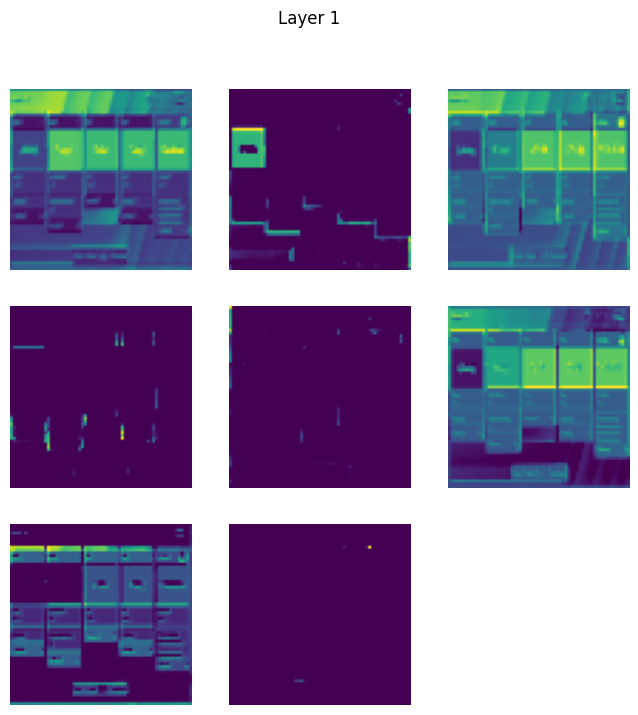

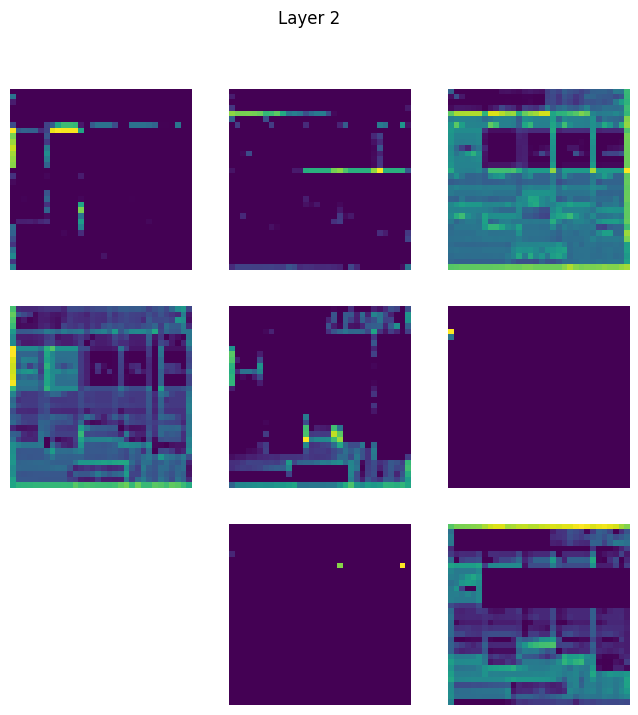

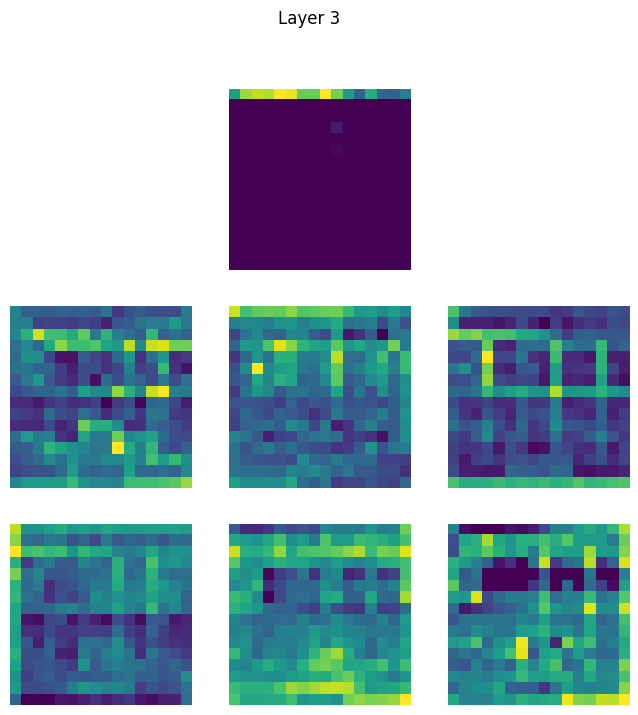

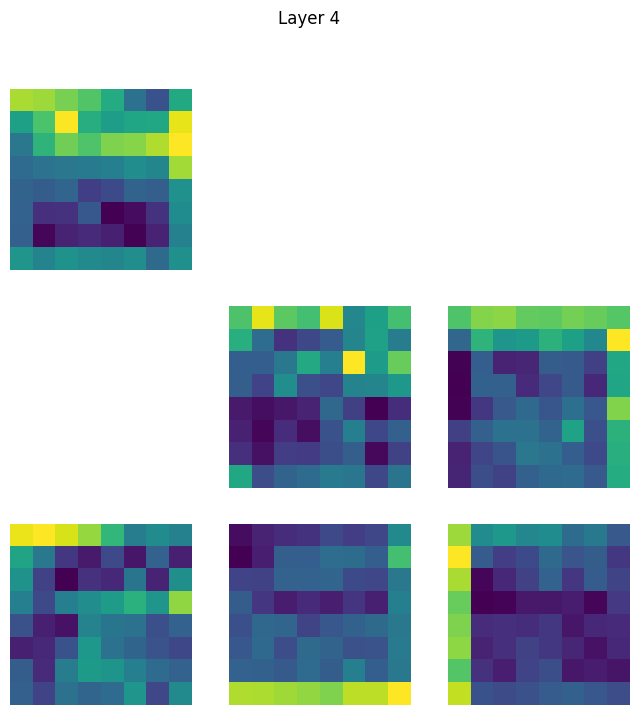

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

image = Image.open("/content/test.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image = transform(image).unsqueeze(0)

conv1 = nn.Conv2d(3, 8, 3, padding=1)
conv2 = nn.Conv2d(8, 16, 3, padding=1)
conv3 = nn.Conv2d(16, 32, 3, padding=1)
conv4 = nn.Conv2d(32, 64, 3, padding=1)

pool = nn.MaxPool2d(2, 2)

outputs = []

x = image

x = pool(torch.relu(conv1(x)))
outputs.append(x)

x = pool(torch.relu(conv2(x)))
outputs.append(x)

x = pool(torch.relu(conv3(x)))
outputs.append(x)

x = pool(torch.relu(conv4(x)))
outputs.append(x)

def show_feature_maps(feature_maps, title):
    feature_maps = feature_maps.detach()
    num_maps = min(feature_maps.shape[1], 9)

    plt.figure(figsize=(8, 8))
    for i in range(num_maps):
        plt.subplot(3, 3, i+1)
        fm = feature_maps[0, i].cpu()
        fm = (fm - fm.min()) / (fm.max() - fm.min())
        plt.imshow(fm, cmap='viridis')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

for i, out in enumerate(outputs):
    show_feature_maps(out, f"Layer {i+1}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


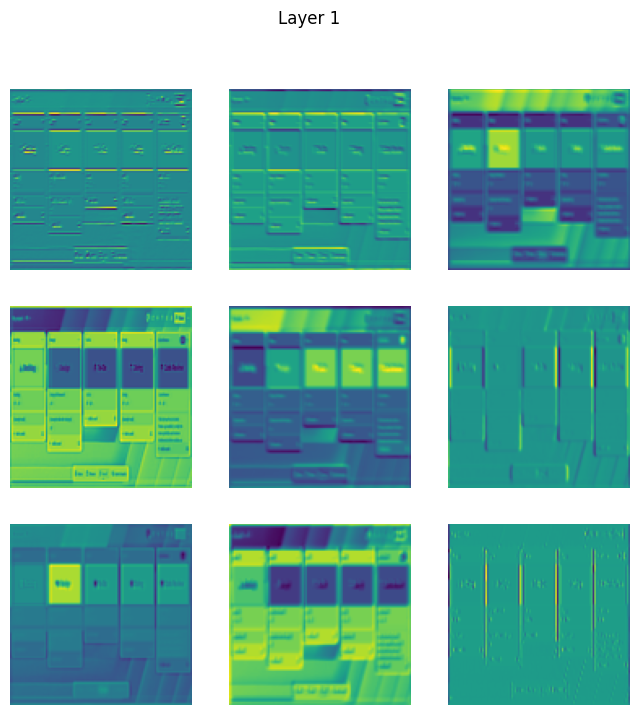

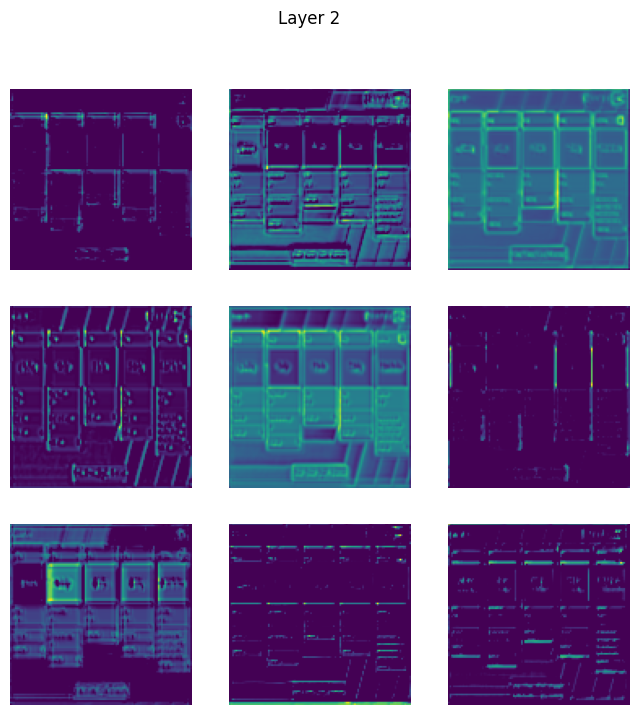

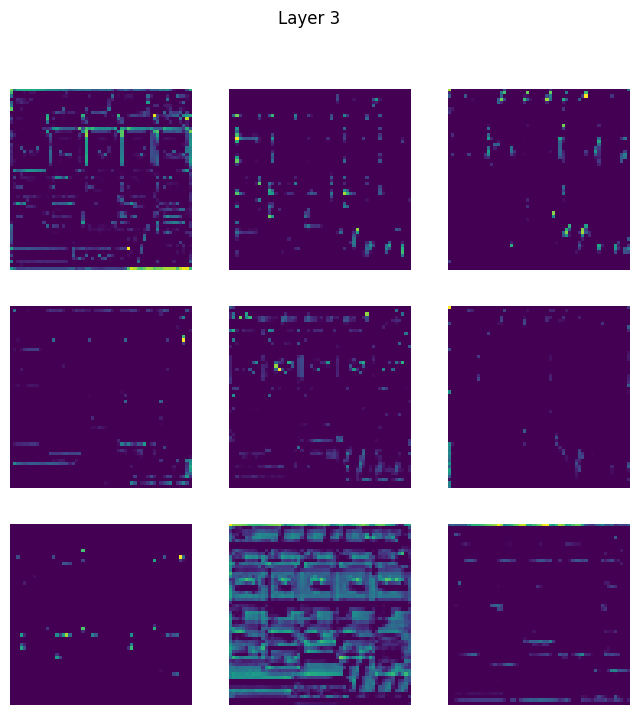

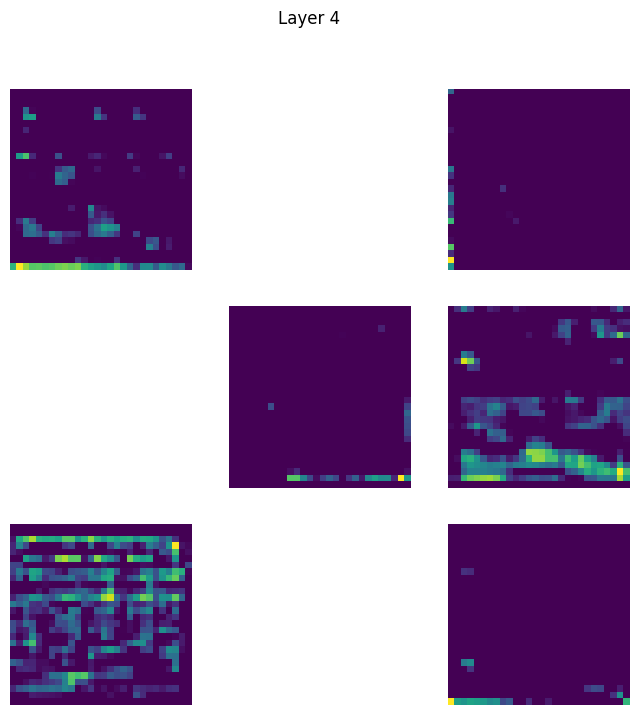

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from torchvision.models import resnet18

image = Image.open("/content/test.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = transform(image).unsqueeze(0)

model = resnet18(pretrained=True)
model.eval()

layers = [
    model.conv1,
    model.layer1,
    model.layer2,
    model.layer3
]

outputs = []

x = image
for layer in layers:
    x = layer(x)
    outputs.append(x)

def show_feature_maps(feature_maps, title):
    feature_maps = feature_maps.detach()
    num_maps = min(feature_maps.shape[1], 9)

    plt.figure(figsize=(8, 8))
    for i in range(num_maps):
        plt.subplot(3, 3, i+1)
        fm = feature_maps[0, i].cpu()
        fm = (fm - fm.min()) / (fm.max() - fm.min())
        plt.imshow(fm, cmap='viridis')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

for i, out in enumerate(outputs):
    show_feature_maps(out, f"Layer {i+1}")

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
from PIL import Image

image = Image.open("/content/test.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = transform(image).unsqueeze(0)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(8 * 112 * 112, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn_model = SimpleCNN()
cnn_output = cnn_model(image)

cnn_pred = torch.argmax(cnn_output, dim=1).item()

resnet = resnet18(pretrained=True)
resnet.eval()

resnet_output = resnet(image)
resnet_pred = torch.argmax(resnet_output, dim=1).item()

print("CNN Prediction:", cnn_pred)
print("ResNet Prediction (ImageNet class index):", resnet_pred)

CNN Prediction: 5
ResNet Prediction (ImageNet class index): 688


Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.2601 - val_loss: 0.2324
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.2108 - val_loss: 0.1925
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.1850 - val_loss: 0.1755
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - loss: 0.1700 - val_loss: 0.1614
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.1573 - val_loss: 0.1512
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.1488 - val_loss: 0.1436
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.1414 - val_loss: 0.1367
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.1346 - val_loss: 0.1302
Epoch 9/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.1290 - val_loss: 0.1249
Epoch 10/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.1241 - val_loss: 0.1205
Epoch 11/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.1202 - val_loss: 0.1169
Epoch 12/40
235/235 ━━━━━━━━━━━━━━

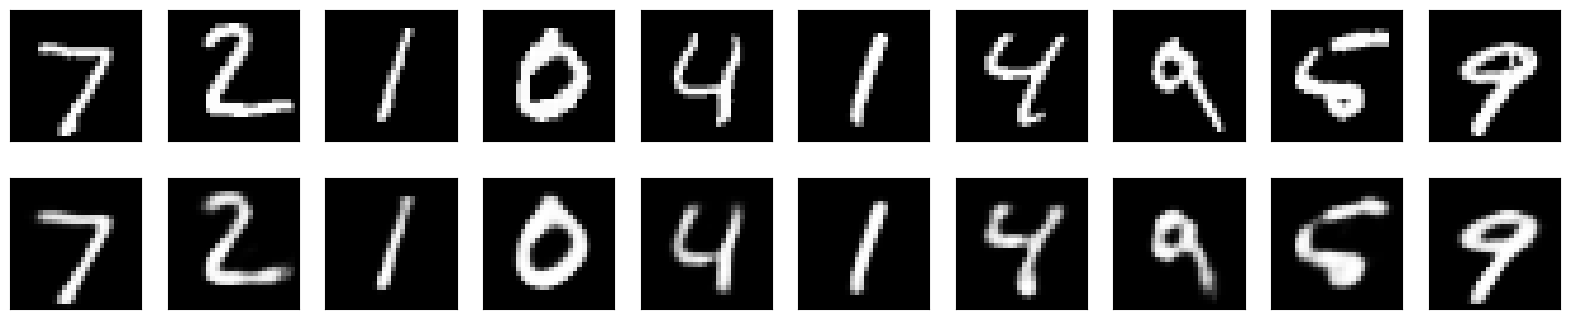

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 62  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)
encoded = Dense(encoding_dim, activation='sigmoid')(encoded)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=40, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

for 30 epochs and activation as sigmoid is giving blur compared to relu



Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2476 - val_loss: 0.1686
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1540 - val_loss: 0.1385
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1321 - val_loss: 0.1250
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1235 - val_loss: 0.1187
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1181 - val_loss: 0.1143
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1140 - val_loss: 0.1107
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.1108 - val_loss: 0.1079
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1082 - val_loss: 0.1056
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1061 - val_loss: 0.1036
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1043 - val_loss: 0.1020
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1028 - val_loss: 0.1008
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

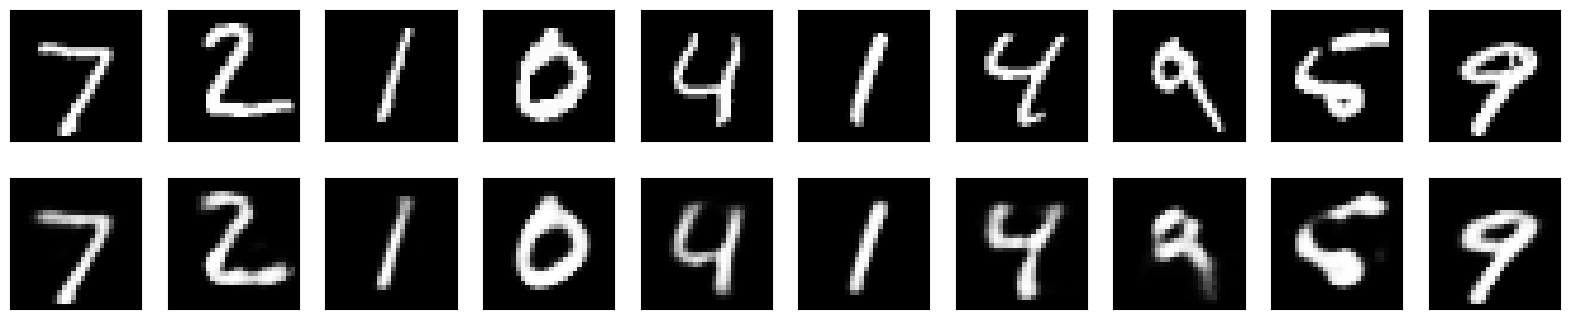

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

adding one more encoding and decoding layer's improved the clarity of imag e, gave beteer results

Regularization in AE

without

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2716 - val_loss: 0.2698
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1916 - val_loss: 0.2239
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1716 - val_loss: 0.2226
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1615 - val_loss: 0.2125
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1559 - val_loss: 0.2097
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1506 - val_loss: 0.2057
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1465 - val_loss: 0.2015
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1430 - val_loss: 0.1924
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1400 - val_loss: 0.1853
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1377 - val_loss: 0.1805
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1360 - val_loss: 0.1727
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

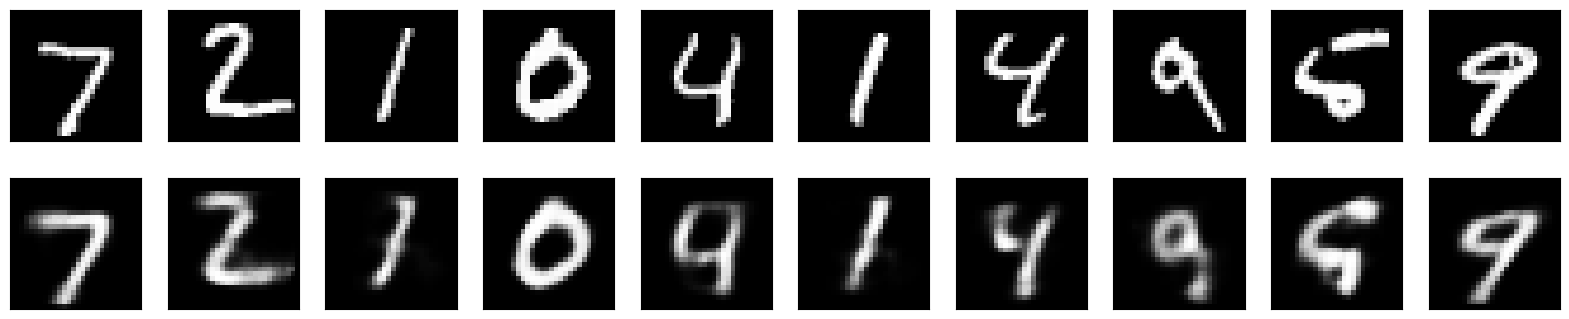

In [21]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector
noise_factor = 0.5

x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


# 6. Test the Model
decoded_normal = autoencoder.predict(x_test_noisy)

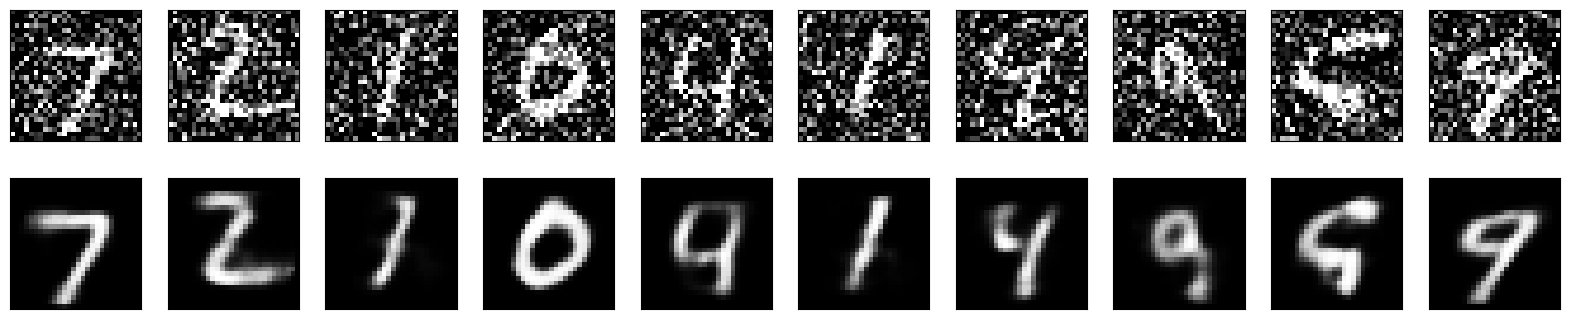

In [23]:

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_normal[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.2598 - val_loss: 0.1792
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.1636 - val_loss: 0.1508
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.1471 - val_loss: 0.1402
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.1388 - val_loss: 0.1347
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.1333 - val_loss: 0.1300
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.1294 - val_loss: 0.1279
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - loss: 0.1264 - val_loss: 0.1276
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.1244 - val_loss: 0.1236
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.1228 - val_loss: 0.1238
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.1214 - val_loss: 0.1263
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.1204 - val_loss: 0.1209
Epoch 12/20
235/235 ━━━━━━━━━━

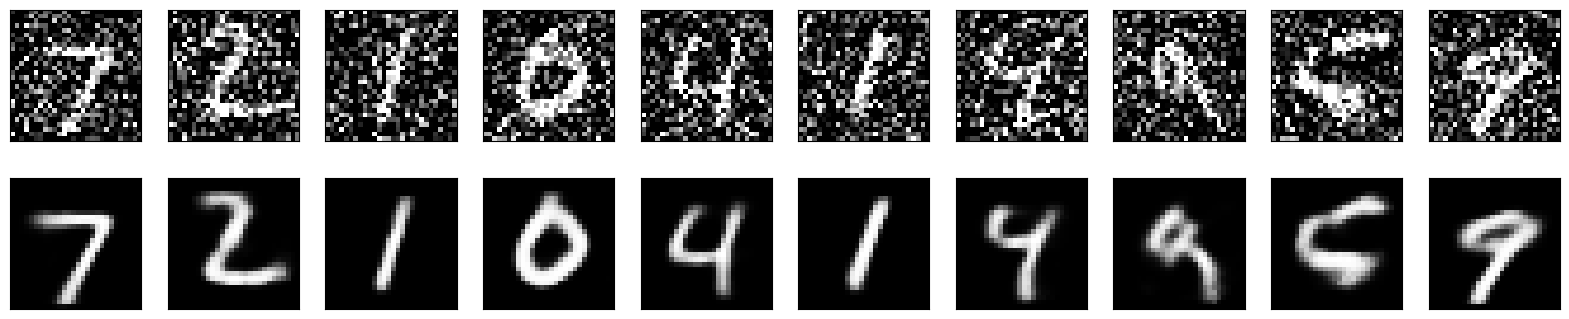

In [22]:
import numpy as np
from tensorflow.keras.layers import Input, Dense, Dropout  # Added Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras import regularizers                # Added regularizers
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# Create Noisy Data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 2. Define the Model
input_layer = Input(shape=(784,))

# Encoder (Gradual compression)
encoded = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(input_layer)
encoded = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoded)
encoded = Dense(128, activation='relu')(encoded)

# Decoder (Symmetric expansion)
decoded = Dense(256, activation='relu')(encoded) # Added this layer for symmetry
decoded = Dense(512, activation='relu')(decoded) # Added this layer for symmetry
decoded = Dense(784, activation='sigmoid')(decoded)

# 3. Create and Compile
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# 5. Test
decoded_reg = autoencoder.predict(x_test_noisy)

# 6. Visualize
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original Noisy Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28)) # Show noisy input to see progress
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed Clean Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_reg[i].reshape(28, 28)) # Fixed variable name
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

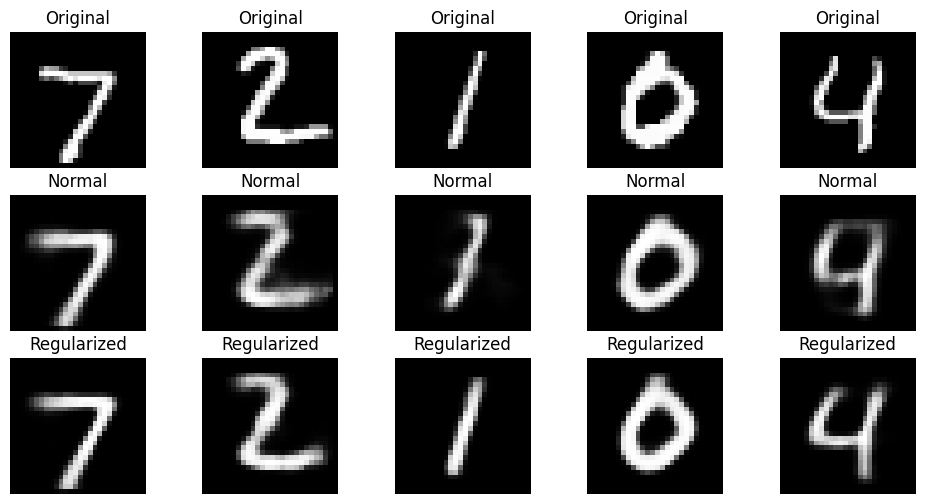

In [24]:
n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.title("Original")
    plt.gray()
    ax.axis("off")

    # Normal AE
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_normal[i].reshape(28, 28))
    plt.title("Normal")
    plt.gray()
    ax.axis("off")

    # Regularized AE
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_reg[i].reshape(28, 28))
    plt.title("Regularized")
    plt.gray()
    ax.axis("off")

plt.show()

Normal AE :

Outputs are distorted / noisy
Struggles to reconstruct properly

 Regularized + Denoising AE:

Outputs are clean and smooth
Digits clearly recognizable

de noising auto encoder

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.2792 - val_loss: 0.1973
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.1872 - val_loss: 0.1709
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.1735 - val_loss: 0.1627
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 0.1674 - val_loss: 0.1579
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 0.1635 - val_loss: 0.1541
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.1604 - val_loss: 0.1511
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.1581 - val_loss: 0.1491
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.1563 - val_loss: 0.1470
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.1547 - val_loss: 0.1453
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.1533 - val_loss: 0.1436
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.1520 - val_loss: 0.1424
Epoch 12/20
235/235 ━━━━━━━━━━━

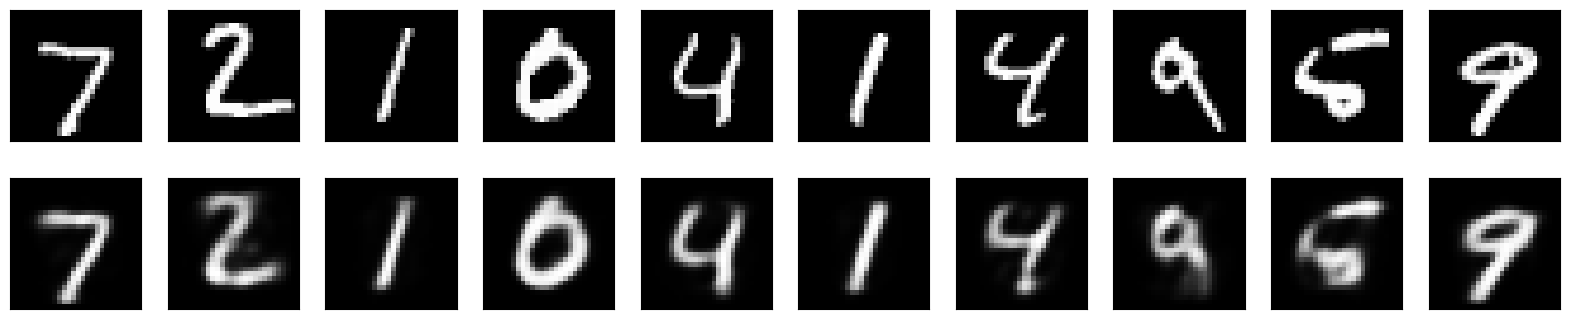

In [16]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(512, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(input_layer)

encoded = Dropout(0.3)(encoded)

encoded = Dense(256, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(encoded)

encoded = Dropout(0.3)(encoded)

encoded = Dense(128, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))


# 6. Test the Model
decoded_reg = autoencoder.predict(x_test_noisy)
# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_reg[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


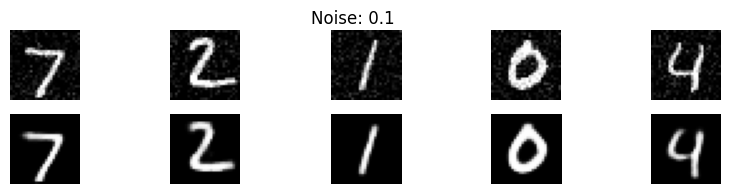

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


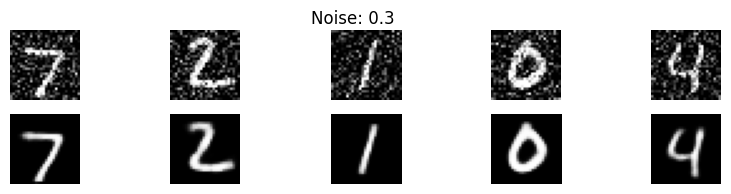

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


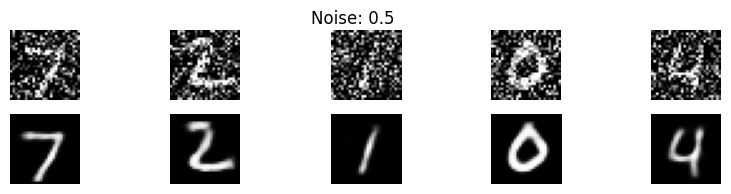

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


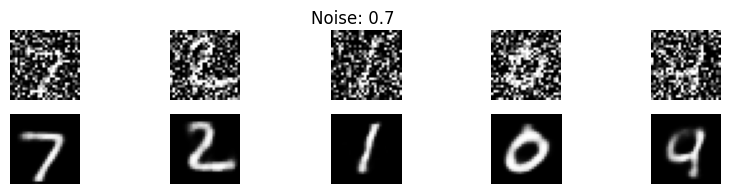

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


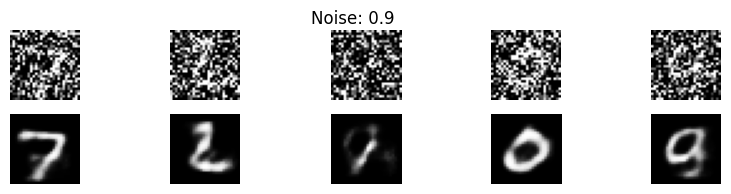

In [26]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

for noise_factor in noise_levels:
    x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)

    decoded_imgs = autoencoder.predict(x_test_noisy)

    plt.figure(figsize=(10,2))
    plt.suptitle(f"Noise: {noise_factor}")

    for i in range(5):
        plt.subplot(2,5,i+1)
        plt.imshow(x_test_noisy[i].reshape(28,28))
        plt.axis("off")

        plt.subplot(2,5,i+6)
        plt.imshow(decoded_imgs[i].reshape(28,28))
        plt.axis("off")

    plt.show()

Acceptable noise range:

0.1 – 0.3 → very good reconstruction

0.4 – 0.6 → moderate quality

>= 0.7 → image structure breaks